# Benchmarking – Baseline Simulation Studies:
## 1) Imports and Set-Up:

### 1.1) Imports & Seed-Setting:

In [28]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

In [29]:
import multiprocessing
import os, random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

We set random seeds:

In [30]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [31]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass

    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 3

    return max(1, n_cores - 1)


N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [32]:
PROVIDE_TEX_OUTPUT = True

In [33]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


### 1.2) Helper-Functions:

In [34]:
from benchmarking_runners import benchmark_cluster_metrics, benchmark_scaling
from benchmarking_plotting import (
    plot_examples,
    plot_ari_over_difficulty,
    plot_baseline_vs_metric_ari_grid,
    plot_paper_figure,
)
from benchmarking_reporting import summarize_regime_tables

---

## 2) Default Benchmarks:

### 2.1) Gaussians Mixtures:

In [35]:
settings_by_k_gaussians = {
    3: {
        "easy": {"cluster_scale": [4.0] * 3, "cluster_size_dirichlet_alpha": 0.9},
        "medium": {"cluster_scale": [4.5] * 3, "cluster_size_dirichlet_alpha": 0.5},
        "hard": {"cluster_scale": [4.6] * 3, "cluster_size_dirichlet_alpha": 0.1},
    },
    4: {
        "easy": {"cluster_scale": [4.0] * 4, "cluster_size_dirichlet_alpha": 0.9},
        "medium": {"cluster_scale": [4.3] * 4, "cluster_size_dirichlet_alpha": 0.3},
        "hard": {"cluster_scale": [4.3] * 4, "cluster_size_dirichlet_alpha": 0.1},
    },
    5: {
        "easy": {"cluster_scale": [4.0] * 5, "cluster_size_dirichlet_alpha": 0.9},
        "medium": {"cluster_scale": [4.5] * 5, "cluster_size_dirichlet_alpha": 0.5},
        "hard": {"cluster_scale": [4.6] * 5, "cluster_size_dirichlet_alpha": 0.2},
    },
    6: {
        "easy": {"cluster_scale": [4.0] * 6, "cluster_size_dirichlet_alpha": 0.9},
        "medium": {"cluster_scale": [4.5] * 6, "cluster_size_dirichlet_alpha": 0.5},
        "hard": {"cluster_scale": [4.6] * 6, "cluster_size_dirichlet_alpha": 0.2},
    },
}

other_settings_gaussians = {"n_total": 500, "p": 50}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_gaussians,
    other_settings=other_settings_gaussians,
    estimator_type="kmeans",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [36]:
results_path = "../results/results_gaussian.csv"

if not os.path.exists(results_path):
    results_gaussian = benchmark_cluster_metrics(
        settings_by_k_gaussians,
        other_settings_gaussians,
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_gaussian.to_csv(results_path, index=False)

else:
    results_gaussian = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_gaussians,
    other_settings_gaussians,
    get_snapshot=True,
    snapshot_df=results_gaussian,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED + 1,
)

_ = plot_ari_over_difficulty(results_gaussian, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_gaussian)

In [9]:
tables_gaussian = summarize_regime_tables(results_gaussian, true_ks=(3, 4))
display(tables_gaussian["ari_df"])
display(tables_gaussian["k_recovery_df"])

k*                        Metric      3                    4              
Difficulty                         easy medium   hard   easy medium   hard
0              Baseline (Oracle)  0.959  0.881  0.738  0.916  0.873  0.711
1                            ---    NaN    NaN    NaN    NaN    NaN    NaN
2                ARI (stab, 1SE)  0.927  0.846  0.764  0.861  0.798  0.754
3                 ARI (gen, 1SE)  0.824  0.797  0.756  0.777  0.706  0.702
4                            ---    NaN    NaN    NaN    NaN    NaN    NaN
5                             DB  0.959  0.880  0.776  0.932  0.893  0.828
6                     Silhouette  0.925  0.833  0.766  0.922  0.767  0.717
7                             CH  0.766  0.729  0.740  0.529  0.635  0.701
8                            Gap  0.733  0.622  0.270  0.800  0.531  0.390
9                            ---    NaN    NaN    NaN    NaN    NaN    NaN
10          ARI (stab, quantile)  0.957  0.877  0.780  0.912  0.858  0.795
11                   Gini (stab)  0.927  0.846  0.764  0.884  0.791  0.773
12               ARI (stab, max)  0.927  0.846  0.764  0.861  0.798  0.755
13           ARI (gen, quantile)  0.919  0.812  0.545  0.859  0.816  0.787
14                ARI (gen, max)  0.817  0.797  0.756  0.763  0.706  0.702
15               Misclass. (gen)  0.803  0.785  0.756  0.696  0.670  0.702

k*                        Metric     3                  4             
Difficulty                        easy medium  hard  easy medium  hard
0              Baseline (Oracle)   NaN    NaN   NaN   NaN    NaN   NaN
1                            ---   NaN    NaN   NaN   NaN    NaN   NaN
2                ARI (stab, 1SE)  0.80   0.55  0.10  0.65   0.30  0.10
3                 ARI (gen, 1SE)  0.25   0.25  0.05  0.20   0.00  0.00
4                            ---   NaN    NaN   NaN   NaN    NaN   NaN
5                             DB  1.00   0.95  0.90  0.95   0.95  0.60
6                     Silhouette  0.75   0.45  0.10  0.85   0.40  0.05
7                             CH  0.05   0.05  0.00  0.00   0.00  0.00
8                            Gap  0.45   0.40  0.05  0.60   0.05  0.00
9                            ---   NaN    NaN   NaN   NaN    NaN   NaN
10          ARI (stab, quantile)  0.95   0.80  0.30  0.90   0.55  0.20
11                   Gini (stab)  0.80   0.55  0.10  0.70   0.30  0.15
12               ARI (stab, max)  0.80   0.55  0.10  0.65   0.30  0.10
13           ARI (gen, quantile)  0.80   0.40  0.25  0.45   0.25  0.05
14                ARI (gen, max)  0.20   0.25  0.05  0.20   0.00  0.00
15               Misclass. (gen)  0.15   0.20  0.05  0.05   0.00  0.00

In [10]:
if PROVIDE_TEX_OUTPUT:
    print(tables_gaussian["ari_tex"])
    print(tables_gaussian["k_recovery_tex"])

\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{$k^* = 3$} & \multicolumn{3}{c}{$k^* = 4$} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Metric & easy & medium & hard & easy & medium & hard \\
\midrule
Baseline (Oracle) & 0.959 & 0.881 & 0.738 & 0.916 & 0.873 & 0.711 \\
\midrule
ARI (stab, 1SE) & 0.927 & 0.846 & 0.764 & 0.861 & 0.798 & 0.754 \\
ARI (gen, 1SE) & 0.824 & 0.797 & 0.756 & 0.777 & 0.706 & 0.702 \\
\midrule
DB & \textbf{0.959} & \textbf{0.880} & \underline{0.776} & \textbf{0.932} & \textbf{0.893} & \textbf{0.828} \\
Silhouette & 0.925 & 0.833 & 0.766 & \underline{0.922} & 0.767 & 0.717 \\
CH & 0.766 & 0.729 & 0.740 & 0.529 & 0.635 & 0.701 \\
Gap & 0.733 & 0.622 & 0.270 & 0.800 & 0.531 & 0.390 \\
\midrule
ARI (stab, quantile) & \underline{0.957} & \underline{0.877} & \textbf{0.780} & 0.912 & \underline{0.858} & \underline{0.795} \\
Gini (stab) & 0.927 & 0.846 & 0.764 & 0.884 & 0.791 & 0.773 \\
ARI (stab, max) & 0.927 & 0.846 & 0.764 & 0.861 & 0.798 & 0.755 \\
ARI (gen, qua

---

### 2.2) t-Distributed Mixtures:

In [37]:
settings_by_k_t_dist = {
    3: {
        "easy": {
            "cluster_scale": [4.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
        },
        "medium": {
            "cluster_scale": [4.0, 1.2, 1.0],
            "cluster_size_dirichlet_alpha": 0.3,
            "t_df": 4,
        },
        "hard": {
            "cluster_scale": [4.0, 1.3, 1.0],
            "cluster_size_dirichlet_alpha": 0.3,
            "t_df": 3,
        },
    },
    4: {
        "easy": {
            "cluster_scale": [3.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
        },
        "medium": {
            "cluster_scale": [4.0, 2.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.2,
            "t_df": 4,
        },
        "hard": {
            "cluster_scale": [4.0, 2.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.1,
            "t_df": 3,
        },
    },
    5: {
        "easy": {
            "cluster_scale": [3.0, 2.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
        },
        "medium": {
            "cluster_scale": [4.0, 2.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "t_df": 4,
        },
        "hard": {
            "cluster_scale": [4.0, 2.0, 2.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.1,
            "t_df": 3,
        },
    },
    6: {
        "easy": {
            "cluster_scale": [3.0, 2.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
        },
        "medium": {
            "cluster_scale": [4.0, 2.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "t_df": 4,
        },
        "hard": {
            "cluster_scale": [4.0, 2.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.2,
            "t_df": 3,
        },
    },
}

other_settings_t_dist = {"n_total": 500, "p": 50, "distribution": "t"}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_t_dist,
    other_settings=other_settings_t_dist,
    estimator_type="agglomerative",
    example_title="t-Distributed Mixtures",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [38]:
results_path = "../results/results_t_dist.csv"

if not os.path.exists(results_path):
    results_t_dist = benchmark_cluster_metrics(
        settings_by_k_t_dist,
        other_settings_t_dist,
        estimator="agglomerative",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_t_dist.to_csv(results_path, index=False)

else:
    results_t_dist = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_t_dist,
    other_settings_t_dist,
    estimator="agglomerative",
    get_snapshot=True,
    snapshot_df=results_t_dist,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_t_dist, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_t_dist)

In [12]:
tables_t_dist = summarize_regime_tables(results_t_dist, true_ks=(3, 4))
display(tables_t_dist["ari_df"])
display(tables_t_dist["k_recovery_df"])

k*                        Metric      3                    4              
Difficulty                         easy medium   hard   easy medium   hard
0              Baseline (Oracle)  0.929  0.865  0.661  0.982  0.797  0.764
1                            ---    NaN    NaN    NaN    NaN    NaN    NaN
2                 ARI (gen, 1SE)  0.968  0.943  0.904  0.917  0.873  0.818
3                ARI (stab, 1SE)  0.920  0.958  0.891  0.849  0.787  0.806
4                            ---    NaN    NaN    NaN    NaN    NaN    NaN
5                            Gap  0.960  0.951  0.910  0.979  0.903  0.855
6                             DB  0.853  0.849  0.378  0.946  0.666  0.393
7                     Silhouette  0.807  0.745  0.346  0.930  0.616  0.387
8                             CH  0.753  0.746  0.411  0.782  0.567  0.375
9                            ---    NaN    NaN    NaN    NaN    NaN    NaN
10           ARI (gen, quantile)  0.971  0.956  0.910  0.973  0.894  0.825
11          ARI (stab, quantile)  0.975  0.957  0.910  0.893  0.894  0.825
12                ARI (gen, max)  0.951  0.944  0.904  0.917  0.859  0.809
13               ARI (stab, max)  0.921  0.949  0.886  0.810  0.780  0.801
14                   Gini (stab)  0.921  0.950  0.636  0.819  0.780  0.695
15               Misclass. (gen)  0.923  0.889  0.697  0.892  0.693  0.534

k*                        Metric     3                  4             
Difficulty                        easy medium  hard  easy medium  hard
0              Baseline (Oracle)   NaN    NaN   NaN   NaN    NaN   NaN
1                            ---   NaN    NaN   NaN   NaN    NaN   NaN
2                 ARI (gen, 1SE)  0.05   0.00  0.00  0.05   0.10  0.05
3                ARI (stab, 1SE)  0.35   0.20  0.10  0.15   0.05  0.10
4                            ---   NaN    NaN   NaN   NaN    NaN   NaN
5                            Gap  0.00   0.00  0.00  0.00   0.00  0.00
6                             DB  0.00   0.05  0.00  0.05   0.00  0.10
7                     Silhouette  0.10   0.05  0.15  0.00   0.10  0.05
8                             CH  0.15   0.10  0.05  0.20   0.00  0.05
9                            ---   NaN    NaN   NaN   NaN    NaN   NaN
10           ARI (gen, quantile)  0.00   0.00  0.00  0.00   0.00  0.00
11          ARI (stab, quantile)  0.00   0.05  0.00  0.00   0.00  0.00
12                ARI (gen, max)  0.20   0.00  0.00  0.05   0.15  0.05
13               ARI (stab, max)  0.45   0.25  0.05  0.25   0.05  0.10
14                   Gini (stab)  0.50   0.25  0.05  0.35   0.05  0.10
15               Misclass. (gen)  0.25   0.05  0.00  0.05   0.10  0.05

In [13]:
if PROVIDE_TEX_OUTPUT:
    print(tables_t_dist["ari_tex"])
    print(tables_t_dist["k_recovery_tex"])

\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{$k^* = 3$} & \multicolumn{3}{c}{$k^* = 4$} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Metric & easy & medium & hard & easy & medium & hard \\
\midrule
Baseline (Oracle) & 0.929 & 0.865 & 0.661 & 0.982 & 0.797 & 0.764 \\
\midrule
ARI (gen, 1SE) & 0.968 & 0.943 & 0.904 & 0.917 & 0.873 & 0.818 \\
ARI (stab, 1SE) & 0.920 & \textbf{0.958} & 0.891 & 0.849 & 0.787 & 0.806 \\
\midrule
Gap & 0.960 & 0.951 & \textbf{0.910} & \textbf{0.979} & \textbf{0.903} & \textbf{0.855} \\
DB & 0.853 & 0.849 & 0.378 & 0.946 & 0.666 & 0.393 \\
Silhouette & 0.807 & 0.745 & 0.346 & 0.930 & 0.616 & 0.387 \\
CH & 0.753 & 0.746 & 0.411 & 0.782 & 0.567 & 0.375 \\
\midrule
ARI (gen, quantile) & \underline{0.971} & 0.956 & \textbf{0.910} & \underline{0.973} & \underline{0.894} & \underline{0.825} \\
ARI (stab, quantile) & \textbf{0.975} & \underline{0.957} & \textbf{0.910} & 0.893 & \underline{0.894} & \underline{0.825} \\
ARI (gen, max) & 0.951 & 0.944 & 0.904 & 0

---

### 2.3) t-Distributed Mixtures with Nuisance Dimensions:

In [39]:
settings_by_k_t_dist_noise = {
    3: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
            "corr_strength": 0.1,
            "noise_dims": 512,
        },
        "medium": {
            "cluster_scale": [1.3, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.1,
            "t_df": 4,
            "corr_strength": 0.4,
            "noise_dims": 1536,
        },
        "hard": {
            "cluster_scale": [1.3, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.1,
            "t_df": 3,
            "corr_strength": 0.5,
            "noise_dims": 2048,
        },
    },
    4: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
            "corr_strength": 0.1,
            "noise_dims": 512,
        },
        "medium": {
            "cluster_scale": [1.1, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.3,
            "t_df": 4,
            "corr_strength": 0.3,
            "noise_dims": 1280,
        },
        "hard": {
            "cluster_scale": [1.1, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.2,
            "t_df": 3,
            "corr_strength": 0.5,
            "noise_dims": 1536,
        },
    },
    5: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
            "corr_strength": 0.1,
            "noise_dims": 512,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "t_df": 4,
            "corr_strength": 0.3,
            "noise_dims": 1024,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.4,
            "t_df": 3,
            "corr_strength": 0.5,
            "noise_dims": 1024,
        },
    },
    6: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
            "corr_strength": 0.1,
            "noise_dims": 512,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "t_df": 4,
            "corr_strength": 0.3,
            "noise_dims": 768,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.4,
            "t_df": 3,
            "corr_strength": 0.5,
            "noise_dims": 768,
        },
    },
}

other_settings_t_dist_noise = {
    "n_total": 500,
    "p": 50,
    "corr_type": "ar1",
    "distribution": "t",
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_t_dist_noise,
    other_settings=other_settings_t_dist_noise,
    estimator_type="agglomerative",
    example_title="t-Distributed Mixtures with Nuisance Dimensions",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [40]:
results_path = "../results/results_t_dist_noise.csv"

if not os.path.exists(results_path):
    results_t_dist_noise = benchmark_cluster_metrics(
        settings_by_k_t_dist_noise,
        other_settings_t_dist_noise,
        estimator="agglomerative",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_t_dist_noise.to_csv(results_path, index=False)

else:
    results_t_dist_noise = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_t_dist_noise,
    other_settings_t_dist_noise,
    estimator="agglomerative",
    get_snapshot=True,
    snapshot_df=results_t_dist_noise,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED + 2,
)

_ = plot_ari_over_difficulty(results_t_dist_noise, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_t_dist_noise)

In [15]:
tables_t_dist_noise = summarize_regime_tables(results_t_dist_noise, true_ks=(3, 4))
display(tables_t_dist_noise["ari_df"])
display(tables_t_dist_noise["k_recovery_df"])

k*                        Metric      3                    4              
Difficulty                         easy medium   hard   easy medium   hard
0              Baseline (Oracle)  0.994  0.884  0.738  0.984  0.859  0.772
1                            ---    NaN    NaN    NaN    NaN    NaN    NaN
2                 ARI (gen, 1SE)  0.965  0.900  0.810  0.966  0.835  0.791
3                ARI (stab, 1SE)  0.921  0.927  0.754  0.736  0.901  0.804
4                            ---    NaN    NaN    NaN    NaN    NaN    NaN
5                             DB  0.993  0.856  0.653  0.983  0.862  0.774
6                     Silhouette  0.994  0.834  0.635  0.983  0.825  0.720
7                            Gap  0.941  0.717  0.534  0.888  0.740  0.704
8                             CH  0.786  0.777  0.615  0.565  0.627  0.612
9                            ---    NaN    NaN    NaN    NaN    NaN    NaN
10          ARI (stab, quantile)  0.998  0.935  0.838  0.991  0.926  0.869
11           ARI (gen, quantile)  0.998  0.916  0.823  0.991  0.924  0.859
12                ARI (gen, max)  0.947  0.890  0.810  0.966  0.827  0.769
13                   Gini (stab)  0.891  0.884  0.720  0.797  0.927  0.810
14               ARI (stab, max)  0.891  0.858  0.754  0.721  0.887  0.794
15               Misclass. (gen)  0.914  0.837  0.688  0.874  0.760  0.703

k*                        Metric     3                  4             
Difficulty                        easy medium  hard  easy medium  hard
0              Baseline (Oracle)   NaN    NaN   NaN   NaN    NaN   NaN
1                            ---   NaN    NaN   NaN   NaN    NaN   NaN
2                 ARI (gen, 1SE)  0.80   0.50  0.30  0.85   0.35  0.25
3                ARI (stab, 1SE)  0.70   0.90  0.70  0.35   0.85  0.50
4                            ---   NaN    NaN   NaN   NaN    NaN   NaN
5                             DB  0.65   0.40  0.20  0.80   0.40  0.10
6                     Silhouette  0.80   0.30  0.10  0.85   0.40  0.15
7                            Gap  0.65   0.20  0.25  0.60   0.35  0.20
8                             CH  0.00   0.00  0.00  0.00   0.00  0.00
9                            ---   NaN    NaN   NaN   NaN    NaN   NaN
10          ARI (stab, quantile)  0.95   0.75  0.30  0.95   0.65  0.30
11           ARI (gen, quantile)  0.95   0.30  0.20  1.00   0.55  0.10
12                ARI (gen, max)  0.70   0.40  0.35  0.85   0.20  0.15
13                   Gini (stab)  0.55   0.85  0.50  0.50   0.95  0.35
14               ARI (stab, max)  0.55   0.75  0.65  0.25   0.80  0.50
15               Misclass. (gen)  0.50   0.25  0.05  0.55   0.05  0.00

In [16]:
if PROVIDE_TEX_OUTPUT:
    print(tables_t_dist_noise["ari_tex"])
    print(tables_t_dist_noise["k_recovery_tex"])

\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{$k^* = 3$} & \multicolumn{3}{c}{$k^* = 4$} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Metric & easy & medium & hard & easy & medium & hard \\
\midrule
Baseline (Oracle) & 0.994 & 0.884 & 0.738 & 0.984 & 0.859 & 0.772 \\
\midrule
ARI (gen, 1SE) & 0.965 & 0.900 & 0.810 & 0.966 & 0.835 & 0.791 \\
ARI (stab, 1SE) & 0.921 & \underline{0.927} & 0.754 & 0.736 & 0.901 & 0.804 \\
\midrule
DB & 0.993 & 0.856 & 0.653 & 0.983 & 0.862 & 0.774 \\
Silhouette & 0.994 & 0.834 & 0.635 & 0.983 & 0.825 & 0.720 \\
Gap & 0.941 & 0.717 & 0.534 & 0.888 & 0.740 & 0.704 \\
CH & 0.786 & 0.777 & 0.615 & 0.565 & 0.627 & 0.612 \\
\midrule
ARI (stab, quantile) & \textbf{0.998} & \textbf{0.935} & \textbf{0.838} & \textbf{0.991} & \underline{0.926} & \textbf{0.869} \\
ARI (gen, quantile) & \textbf{0.998} & 0.916 & \underline{0.823} & \textbf{0.991} & 0.924 & \underline{0.859} \\
ARI (gen, max) & 0.947 & 0.890 & 0.810 & 0.966 & 0.827 & 0.769 \\
Gini (stab) & 0.891 &

---

### 2.4) RFF Embedded Circles:

In [41]:
settings_by_k_circles = {
    3: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 12.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 12.0,
        },
    },
    4: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 10.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 8.0,
        },
    },
    5: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 12.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 6.0,
        },
    },
    6: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 6.0,
        },
        "hard": {
            "cluster_scale": [2.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 6.0,
        },
    },
}

other_settings_circles = {
    "n_total": 500,
    "p": 50,
    "corr_type": "ar1",
    "distribution": "circles",
    "nonlinear": True,
    "embed_dim": 64,
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_circles,
    other_settings=other_settings_circles,
    estimator_type="spectral",
    example_title="RFF Embedded Circles",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [42]:
results_path = "../results/results_circles.csv"

if not os.path.exists(results_path):
    results_circles = benchmark_cluster_metrics(
        settings_by_k_circles,
        other_settings_circles,
        estimator="spectral",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_circles.to_csv(results_path, index=False)

else:
    results_circles = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_circles,
    other_settings_circles,
    estimator="spectral",
    get_snapshot=True,
    snapshot_df=results_circles,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_circles, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_circles)

In [18]:
tables_circles = summarize_regime_tables(results_circles, true_ks=(3, 4))
display(tables_circles["ari_df"])
display(tables_circles["k_recovery_df"])

k*                        Metric      3                    4              
Difficulty                         easy medium   hard   easy medium   hard
0              Baseline (Oracle)  0.937  0.863  0.712  0.927  0.930  0.731
1                            ---    NaN    NaN    NaN    NaN    NaN    NaN
2                ARI (stab, 1SE)  0.883  0.788  0.699  0.914  0.885  0.714
3                 ARI (gen, 1SE)  0.857  0.731  0.656  0.842  0.829  0.715
4                            ---    NaN    NaN    NaN    NaN    NaN    NaN
5                     Silhouette  0.593  0.409  0.400  0.688  0.710  0.531
6                             CH  0.564  0.418  0.411  0.693  0.670  0.534
7                             DB  0.548  0.414  0.396  0.678  0.598  0.534
8                            Gap  0.521  0.394  0.389  0.641  0.549  0.497
9                            ---    NaN    NaN    NaN    NaN    NaN    NaN
10          ARI (stab, quantile)  0.875  0.766  0.709  0.877  0.827  0.703
11               Misclass. (gen)  0.848  0.762  0.660  0.847  0.814  0.722
12                ARI (gen, max)  0.864  0.758  0.656  0.842  0.809  0.722
13               ARI (stab, max)  0.786  0.763  0.656  0.750  0.794  0.670
14                   Gini (stab)  0.771  0.738  0.634  0.715  0.793  0.682
15           ARI (gen, quantile)  0.701  0.540  0.529  0.690  0.731  0.566

k*                        Metric     3                  4             
Difficulty                        easy medium  hard  easy medium  hard
0              Baseline (Oracle)   NaN    NaN   NaN   NaN    NaN   NaN
1                            ---   NaN    NaN   NaN   NaN    NaN   NaN
2                ARI (stab, 1SE)  0.70   0.55  0.40  0.70   0.55  0.30
3                 ARI (gen, 1SE)  0.65   0.40  0.30  0.35   0.40  0.25
4                            ---   NaN    NaN   NaN   NaN    NaN   NaN
5                     Silhouette  0.05   0.00  0.00  0.05   0.30  0.00
6                             CH  0.05   0.00  0.00  0.10   0.30  0.00
7                             DB  0.00   0.00  0.00  0.00   0.00  0.00
8                            Gap  0.00   0.00  0.00  0.00   0.00  0.00
9                            ---   NaN    NaN   NaN   NaN    NaN   NaN
10          ARI (stab, quantile)  0.70   0.55  0.45  0.60   0.45  0.20
11               Misclass. (gen)  0.60   0.30  0.30  0.45   0.35  0.10
12                ARI (gen, max)  0.65   0.40  0.30  0.40   0.35  0.30
13               ARI (stab, max)  0.40   0.40  0.25  0.35   0.30  0.20
14                   Gini (stab)  0.35   0.30  0.20  0.30   0.30  0.25
15           ARI (gen, quantile)  0.25   0.15  0.10  0.10   0.30  0.00

In [19]:
if PROVIDE_TEX_OUTPUT:
    print(tables_circles["ari_tex"])
    print(tables_circles["k_recovery_tex"])

\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{$k^* = 3$} & \multicolumn{3}{c}{$k^* = 4$} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Metric & easy & medium & hard & easy & medium & hard \\
\midrule
Baseline (Oracle) & 0.937 & 0.863 & 0.712 & 0.927 & 0.930 & 0.731 \\
\midrule
ARI (stab, 1SE) & \textbf{0.883} & \textbf{0.788} & \underline{0.699} & \textbf{0.914} & \textbf{0.885} & 0.714 \\
ARI (gen, 1SE) & 0.857 & 0.731 & 0.656 & 0.842 & \underline{0.829} & 0.715 \\
\midrule
Silhouette & 0.593 & 0.409 & 0.400 & 0.688 & 0.710 & 0.531 \\
CH & 0.564 & 0.418 & 0.411 & 0.693 & 0.670 & 0.534 \\
DB & 0.548 & 0.414 & 0.396 & 0.678 & 0.598 & 0.534 \\
Gap & 0.521 & 0.394 & 0.389 & 0.641 & 0.549 & 0.497 \\
\midrule
ARI (stab, quantile) & \underline{0.875} & \underline{0.766} & \textbf{0.709} & \underline{0.877} & 0.827 & 0.703 \\
Misclass. (gen) & 0.848 & 0.762 & 0.660 & 0.847 & 0.814 & \textbf{0.722} \\
ARI (gen, max) & 0.864 & 0.758 & 0.656 & 0.842 & 0.809 & \textbf{0.722} \\
ARI (stab, ma

---

### 2.5) RFF Embedded Moons:

In [43]:
settings_by_k_moons = {
    3: {
        "easy": {
            "cluster_scale": [1.0, 0.5, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 12.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 12.0,
        },
    },
    4: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 0.5, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 10.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 8.0,
        },
    },
    5: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 10.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 6.0,
        },
    },
    6: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 6.0,
        },
        "hard": {
            "cluster_scale": [2.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 6.0,
        },
    },
}

other_settings_moons = {
    "n_total": 500,
    "p": 50,
    "corr_type": "ar1",
    "distribution": "moons",
    "nonlinear": True,
    "embed_dim": 64,
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_moons,
    other_settings=other_settings_moons,
    estimator_type="spectral",
    example_title="RFF Embedded Moons",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [44]:
results_path = "../results/results_moons.csv"

if not os.path.exists(results_path):
    results_moons = benchmark_cluster_metrics(
        settings_by_k_moons,
        other_settings_moons,
        estimator="spectral",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_moons.to_csv(results_path, index=False)

else:
    results_moons = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_moons,
    other_settings_moons,
    estimator="spectral",
    get_snapshot=True,
    snapshot_df=results_moons,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_moons, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_moons)

In [21]:
tables_moons = summarize_regime_tables(results_moons, true_ks=(3, 4))
display(tables_moons["ari_df"])
display(tables_moons["k_recovery_df"])

k*                        Metric      3                    4              
Difficulty                         easy medium   hard   easy medium   hard
0              Baseline (Oracle)  0.894  0.842  0.649  0.940  0.797  0.746
1                            ---    NaN    NaN    NaN    NaN    NaN    NaN
2                ARI (stab, 1SE)  0.843  0.827  0.625  0.915  0.690  0.681
3                 ARI (gen, 1SE)  0.796  0.779  0.589  0.862  0.659  0.671
4                            ---    NaN    NaN    NaN    NaN    NaN    NaN
5                     Silhouette  0.729  0.463  0.432  0.793  0.607  0.567
6                             DB  0.578  0.457  0.432  0.757  0.605  0.574
7                             CH  0.511  0.454  0.432  0.695  0.604  0.578
8                            Gap  0.493  0.452  0.432  0.679  0.578  0.537
9                            ---    NaN    NaN    NaN    NaN    NaN    NaN
10          ARI (stab, quantile)  0.828  0.780  0.587  0.901  0.664  0.684
11               Misclass. (gen)  0.806  0.783  0.668  0.852  0.648  0.667
12                ARI (gen, max)  0.799  0.823  0.589  0.873  0.633  0.648
13               ARI (stab, max)  0.833  0.811  0.625  0.731  0.680  0.677
14                   Gini (stab)  0.784  0.786  0.625  0.709  0.613  0.655
15           ARI (gen, quantile)  0.652  0.544  0.495  0.815  0.599  0.583

k*                        Metric     3                  4             
Difficulty                        easy medium  hard  easy medium  hard
0              Baseline (Oracle)   NaN    NaN   NaN   NaN    NaN   NaN
1                            ---   NaN    NaN   NaN   NaN    NaN   NaN
2                ARI (stab, 1SE)  0.40   0.50  0.20  0.60   0.05  0.10
3                 ARI (gen, 1SE)  0.25   0.45  0.15  0.40   0.05  0.20
4                            ---   NaN    NaN   NaN   NaN    NaN   NaN
5                     Silhouette  0.10   0.00  0.00  0.05   0.05  0.00
6                             DB  0.00   0.00  0.00  0.00   0.05  0.00
7                             CH  0.05   0.00  0.00  0.05   0.05  0.00
8                            Gap  0.00   0.00  0.00  0.00   0.00  0.00
9                            ---   NaN    NaN   NaN   NaN    NaN   NaN
10          ARI (stab, quantile)  0.40   0.45  0.20  0.55   0.05  0.05
11               Misclass. (gen)  0.30   0.35  0.20  0.40   0.00  0.10
12                ARI (gen, max)  0.30   0.45  0.15  0.40   0.00  0.15
13               ARI (stab, max)  0.40   0.40  0.20  0.20   0.05  0.10
14                   Gini (stab)  0.25   0.35  0.15  0.15   0.00  0.10
15           ARI (gen, quantile)  0.20   0.10  0.10  0.30   0.00  0.00

In [22]:
if PROVIDE_TEX_OUTPUT:
    print(tables_moons["ari_tex"])
    print(tables_moons["k_recovery_tex"])

\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{$k^* = 3$} & \multicolumn{3}{c}{$k^* = 4$} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Metric & easy & medium & hard & easy & medium & hard \\
\midrule
Baseline (Oracle) & 0.894 & 0.842 & 0.649 & 0.940 & 0.797 & 0.746 \\
\midrule
ARI (stab, 1SE) & \textbf{0.843} & \textbf{0.827} & \underline{0.625} & \textbf{0.915} & \textbf{0.690} & \underline{0.681} \\
ARI (gen, 1SE) & 0.796 & 0.779 & 0.589 & 0.862 & 0.659 & 0.671 \\
\midrule
Silhouette & 0.729 & 0.463 & 0.432 & 0.793 & 0.607 & 0.567 \\
DB & 0.578 & 0.457 & 0.432 & 0.757 & 0.605 & 0.574 \\
CH & 0.511 & 0.454 & 0.432 & 0.695 & 0.604 & 0.578 \\
Gap & 0.493 & 0.452 & 0.432 & 0.679 & 0.578 & 0.537 \\
\midrule
ARI (stab, quantile) & 0.828 & 0.780 & 0.587 & \underline{0.901} & 0.664 & \textbf{0.684} \\
Misclass. (gen) & 0.806 & 0.783 & \textbf{0.668} & 0.852 & 0.648 & 0.667 \\
ARI (gen, max) & 0.799 & \underline{0.823} & 0.589 & 0.873 & 0.633 & 0.648 \\
ARI (stab, max) & \underline{0.833

---

### 2.6) RFF Embedded Swiss Rolls:

In [45]:
settings_by_k_swiss_rolls = {
    3: {
        "easy": {
            "cluster_scale": [1.0, 0.5, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 12.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 12.0,
        },
    },
    4: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 0.5, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 8.0,
        },
        "hard": {
            "cluster_scale": [2.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 8.0,
        },
    },
    5: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 10.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 5.0,
        },
    },
    6: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 5.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 4.5,
        },
    },
}

other_settings_swiss_rolls = {
    "n_total": 500,
    "p": 50,
    "corr_type": "ar1",
    "distribution": "swiss_roll",
    "nonlinear": True,
    "embed_dim": 64,
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_swiss_rolls,
    other_settings=other_settings_swiss_rolls,
    estimator_type="spectral",
    example_title="RFF Embedded Swiss Rolls",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [46]:
results_path = "../results/results_swiss_rolls.csv"

if not os.path.exists(results_path):
    results_swiss_rolls = benchmark_cluster_metrics(
        settings_by_k_swiss_rolls,
        other_settings_swiss_rolls,
        estimator="spectral",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_swiss_rolls.to_csv(results_path, index=False)

else:
    results_swiss_rolls = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_swiss_rolls,
    other_settings_swiss_rolls,
    estimator="spectral",
    get_snapshot=True,
    snapshot_df=results_swiss_rolls,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_swiss_rolls, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_swiss_rolls)

In [24]:
tables_swiss_rolls = summarize_regime_tables(results_swiss_rolls, true_ks=(3, 4))
display(tables_swiss_rolls["ari_df"])
display(tables_swiss_rolls["k_recovery_df"])

k*                        Metric      3                    4              
Difficulty                         easy medium   hard   easy medium   hard
0              Baseline (Oracle)  0.985  0.908  0.768  0.965  0.728  0.697
1                            ---    NaN    NaN    NaN    NaN    NaN    NaN
2                ARI (stab, 1SE)  0.942  0.828  0.710  0.880  0.722  0.680
3                 ARI (gen, 1SE)  0.921  0.789  0.655  0.927  0.755  0.689
4                            ---    NaN    NaN    NaN    NaN    NaN    NaN
5                     Silhouette  0.857  0.718  0.618  0.833  0.722  0.659
6                             CH  0.747  0.534  0.525  0.810  0.713  0.583
7                             DB  0.682  0.434  0.441  0.729  0.638  0.578
8                            Gap  0.484  0.399  0.400  0.682  0.592  0.537
9                            ---    NaN    NaN    NaN    NaN    NaN    NaN
10               Misclass. (gen)  0.927  0.814  0.712  0.916  0.722  0.726
11                ARI (gen, max)  0.927  0.795  0.680  0.927  0.754  0.697
12          ARI (stab, quantile)  0.961  0.797  0.671  0.880  0.708  0.673
13               ARI (stab, max)  0.804  0.772  0.666  0.811  0.722  0.690
14                   Gini (stab)  0.804  0.772  0.657  0.766  0.709  0.684
15           ARI (gen, quantile)  0.852  0.562  0.535  0.826  0.637  0.608

k*                        Metric     3                  4             
Difficulty                        easy medium  hard  easy medium  hard
0              Baseline (Oracle)   NaN    NaN   NaN   NaN    NaN   NaN
1                            ---   NaN    NaN   NaN   NaN    NaN   NaN
2                ARI (stab, 1SE)  0.85   0.65  0.35  0.65   0.25  0.10
3                 ARI (gen, 1SE)  0.75   0.45  0.25  0.65   0.25  0.05
4                            ---   NaN    NaN   NaN   NaN    NaN   NaN
5                     Silhouette  0.30   0.45  0.25  0.20   0.15  0.15
6                             CH  0.40   0.15  0.10  0.35   0.25  0.05
7                             DB  0.10   0.00  0.00  0.00   0.00  0.00
8                            Gap  0.00   0.00  0.00  0.00   0.00  0.00
9                            ---   NaN    NaN   NaN   NaN    NaN   NaN
10               Misclass. (gen)  0.75   0.35  0.25  0.60   0.20  0.15
11                ARI (gen, max)  0.75   0.40  0.30  0.65   0.30  0.10
12          ARI (stab, quantile)  0.85   0.55  0.30  0.65   0.25  0.05
13               ARI (stab, max)  0.40   0.35  0.25  0.45   0.25  0.15
14                   Gini (stab)  0.40   0.35  0.20  0.35   0.25  0.10
15           ARI (gen, quantile)  0.55   0.20  0.15  0.40   0.05  0.05

In [25]:
if PROVIDE_TEX_OUTPUT:
    print(tables_swiss_rolls["ari_tex"])
    print(tables_swiss_rolls["k_recovery_tex"])

\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{$k^* = 3$} & \multicolumn{3}{c}{$k^* = 4$} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Metric & easy & medium & hard & easy & medium & hard \\
\midrule
Baseline (Oracle) & 0.985 & 0.908 & 0.768 & 0.965 & 0.728 & 0.697 \\
\midrule
ARI (stab, 1SE) & \underline{0.942} & \textbf{0.828} & \underline{0.710} & 0.880 & 0.722 & 0.680 \\
ARI (gen, 1SE) & 0.921 & 0.789 & 0.655 & \textbf{0.927} & \textbf{0.755} & 0.689 \\
\midrule
Silhouette & 0.857 & 0.718 & 0.618 & 0.833 & 0.722 & 0.659 \\
CH & 0.747 & 0.534 & 0.525 & 0.810 & 0.713 & 0.583 \\
DB & 0.682 & 0.434 & 0.441 & 0.729 & 0.638 & 0.578 \\
Gap & 0.484 & 0.399 & 0.400 & 0.682 & 0.592 & 0.537 \\
\midrule
Misclass. (gen) & 0.927 & \underline{0.814} & \textbf{0.712} & 0.916 & 0.722 & \textbf{0.726} \\
ARI (gen, max) & 0.927 & 0.795 & 0.680 & \textbf{0.927} & \underline{0.754} & \underline{0.697} \\
ARI (stab, quantile) & \textbf{0.961} & 0.797 & 0.671 & 0.880 & 0.708 & 0.673 \\
ARI (stab, ma

---

## 3) Scalability Benchmarks:

### 3.1) Gaussians Mixtures:

#### 3.1.1) Dimensionality:

In [ ]:
settings_by_k_gaussians_dimensionality = {
    3: {
        "start": {"cluster_scale": [2] * 3},
        "middle": {"cluster_scale": [4] * 3},
        "end": {"cluster_scale": [8.5] * 3},
    },
    4: {
        "start": {"cluster_scale": [1.75] * 4},
        "middle": {"cluster_scale": [4] * 4},
        "end": {"cluster_scale": [9] * 4},
    },
}

other_settings_gaussians_dimensionality = {
    "corr_type": "ar1",
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_gaussians_dimensionality,
    other_settings=other_settings_gaussians_dimensionality,
    level_label="p",
    example_title="Gaussian Mixtures (Increasing Dimensionality)",
    sampler="scaling",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_gaussian_dimensionality.csv"
runtimes_path = "../results/runtimes_gaussian_dimensionality.csv"

if not os.path.exists(results_path):
    results_gaussian_dimensionality, runtimes_gaussian_dimensionality = (
        benchmark_scaling(
            settings_by_k_gaussians_dimensionality,
            other_settings_gaussians_dimensionality,
            axis_name="p",
            n_jobs=N_JOBS,
            random_state=RANDOM_SEED,
        )
    )

    os.makedirs("../results/", exist_ok=True)
    results_gaussian_dimensionality.to_csv(results_path, index=False)
    runtimes_gaussian_dimensionality.to_csv(runtimes_path, index=False)

else:
    results_gaussian_dimensionality = pd.read_csv(results_path)
    runtimes_gaussian_dimensionality = pd.read_csv(runtimes_path)

In [ ]:
_ = plot_ari_over_difficulty(
    results_gaussian_dimensionality,
)

# _ = plot_baseline_vs_metric_ari_grid(results_gaussian_dimensionality)

#### 3.1.2) Number of Samples:

In [ ]:
settings_by_k_gaussians_samples = {
    3: {
        "start": {"cluster_scale": [3.7] * 3},
        "middle": {"cluster_scale": [4.2] * 3},
        "end": {"cluster_scale": [4.3] * 3},
    },
    4: {
        "start": {"cluster_scale": [3] * 4},
        "middle": {"cluster_scale": [4.3] * 4},
        "end": {"cluster_scale": [4.5] * 4},
    },
}

other_settings_gaussians_samples = {
    "corr_type": "ar1",
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_gaussians_samples,
    other_settings=other_settings_gaussians_samples,
    level_label="n_total",
    example_title="Gaussian Mixtures (Increasing Number of Samples)",
    sampler="scaling",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_gaussian_samples.csv"
runtimes_path = "../results/runtimes_gaussian_samples.csv"

if not os.path.exists(results_path):
    results_gaussian_samples, runtimes_gaussian_samples = benchmark_scaling(
        settings_by_k_gaussians_samples,
        other_settings_gaussians_samples,
        axis_name="n_total",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_gaussian_samples.to_csv(results_path, index=False)
    runtimes_gaussian_samples.to_csv(runtimes_path, index=False)

else:
    results_gaussian_samples = pd.read_csv(results_path)
    runtimes_gaussian_samples = pd.read_csv(runtimes_path)

In [ ]:
_ = plot_ari_over_difficulty(
    results_gaussian_samples,
)

# _ = plot_baseline_vs_metric_ari_grid(results_gaussian_samples)

---

### 3.2) RFF Embedded Moons:

#### 3.2.1) Dimensionality:

In [ ]:
settings_by_k_moons_dimensionality = {
    3: {
        "start": {"cluster_scale": [1.0, 0.5, 0.5], "embed_param": 11.0},
        "middle": {"cluster_scale": [1.0, 0.9, 0.8], "embed_param": 6.5},
        "end": {"cluster_scale": [2.0, 1.0, 1.0], "embed_param": 6.0},
    },
    4: {
        "start": {"cluster_scale": [1.0, 0.5, 0.5, 0.25], "embed_param": 8.0},
        "middle": {"cluster_scale": [1.0, 1.0, 1.0, 1.0], "embed_param": 4.0},
        "end": {"cluster_scale": [1.0, 1.0, 1.0, 1.0], "embed_param": 4.0},
    },
}

other_settings_moons_dimensionality = {
    "corr_type": "ar1",
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
    "distribution": "moons",
    "nonlinear": True,
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_moons_dimensionality,
    other_settings=other_settings_moons_dimensionality,
    level_label="embed_dim",
    estimator_type="spectral",
    spectral_quant=0.5,
    example_title="RFF Embedded Moons (Increasing Dimensionality)",
    sampler="scaling",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_moons_dimensionality.csv"
runtimes_path = "../results/runtimes_moons_dimensionality.csv"

if not os.path.exists(results_path):
    results_moons_dimensionality, runtimes_moons_dimensionality = benchmark_scaling(
        settings_by_k_moons_dimensionality,
        other_settings_moons_dimensionality,
        axis_name="embed_dim",
        estimator="spectral",
        spectral_quant=0.5,
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_moons_dimensionality.to_csv(results_path, index=False)
    runtimes_moons_dimensionality.to_csv(runtimes_path, index=False)

else:
    results_moons_dimensionality = pd.read_csv(results_path)
    runtimes_moons_dimensionality = pd.read_csv(runtimes_path)

In [ ]:
_ = plot_ari_over_difficulty(
    results_moons_dimensionality,
)

# _ = plot_baseline_vs_metric_ari_grid(results_gaussian_dimensionality)

#### 3.2.2) Number of Samples:

In [ ]:
settings_by_k_moons_samples = {
    3: {
        "start": {"cluster_scale": [1.0, 1.0, 0.75], "embed_param": 6.0},
        "middle": {"cluster_scale": [1.0, 1.0, 0.45], "embed_param": 5.0},
        "end": {"cluster_scale": [1.0, 1.0, 0.26], "embed_param": 4.0},
    },
    4: {
        "start": {"cluster_scale": [1.0, 1.0, 1.0, 0.5], "embed_param": 10.0},
        "middle": {"cluster_scale": [1.0, 1.0, 1.0, 1.0], "embed_param": 5.0},
        "end": {"cluster_scale": [1.0, 1.0, 1.0, 0.5], "embed_param": 5.0},
    },
}

other_settings_moons_samples = {
    "corr_type": "ar1",
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
    "distribution": "moons",
    "nonlinear": True,
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_moons_samples,
    other_settings=other_settings_moons_samples,
    level_label="n_total",
    estimator_type="spectral",
    spectral_quant=0.5,
    example_title="RFF Embedded Moons (Increasing Number of Samples)",
    sampler="scaling",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_moons_samples.csv"
runtimes_path = "../results/runtimes_moons_samples.csv"

if not os.path.exists(results_path):
    results_moons_samples, runtimes_moons_samples = benchmark_scaling(
        settings_by_k_moons_samples,
        other_settings_moons_samples,
        axis_name="n_total",
        estimator="spectral",
        spectral_quant=0.5,
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_moons_samples.to_csv(results_path, index=False)
    runtimes_moons_samples.to_csv(runtimes_path, index=False)

else:
    results_moons_samples = pd.read_csv(results_path)
    runtimes_moons_samples = pd.read_csv(runtimes_path)

In [ ]:
_ = plot_ari_over_difficulty(
    results_moons_samples,
)

# _ = plot_baseline_vs_metric_ari_grid(results_gaussian_dimensionality)

---

## 4) Overview – All Regimes:

### Paper Figure 3 — Per-k* Overview (Examples + Lineplots):

In [47]:
regimes = [
    ("Gaussians", results_gaussian),
    ("t-Distributed", results_t_dist),
    ("t-Distributed + Nuisance Dims", results_t_dist_noise),
    ("RFF Circles", results_circles),
    ("RFF Moons", results_moons),
    ("RFF Swiss Rolls", results_swiss_rolls),
]

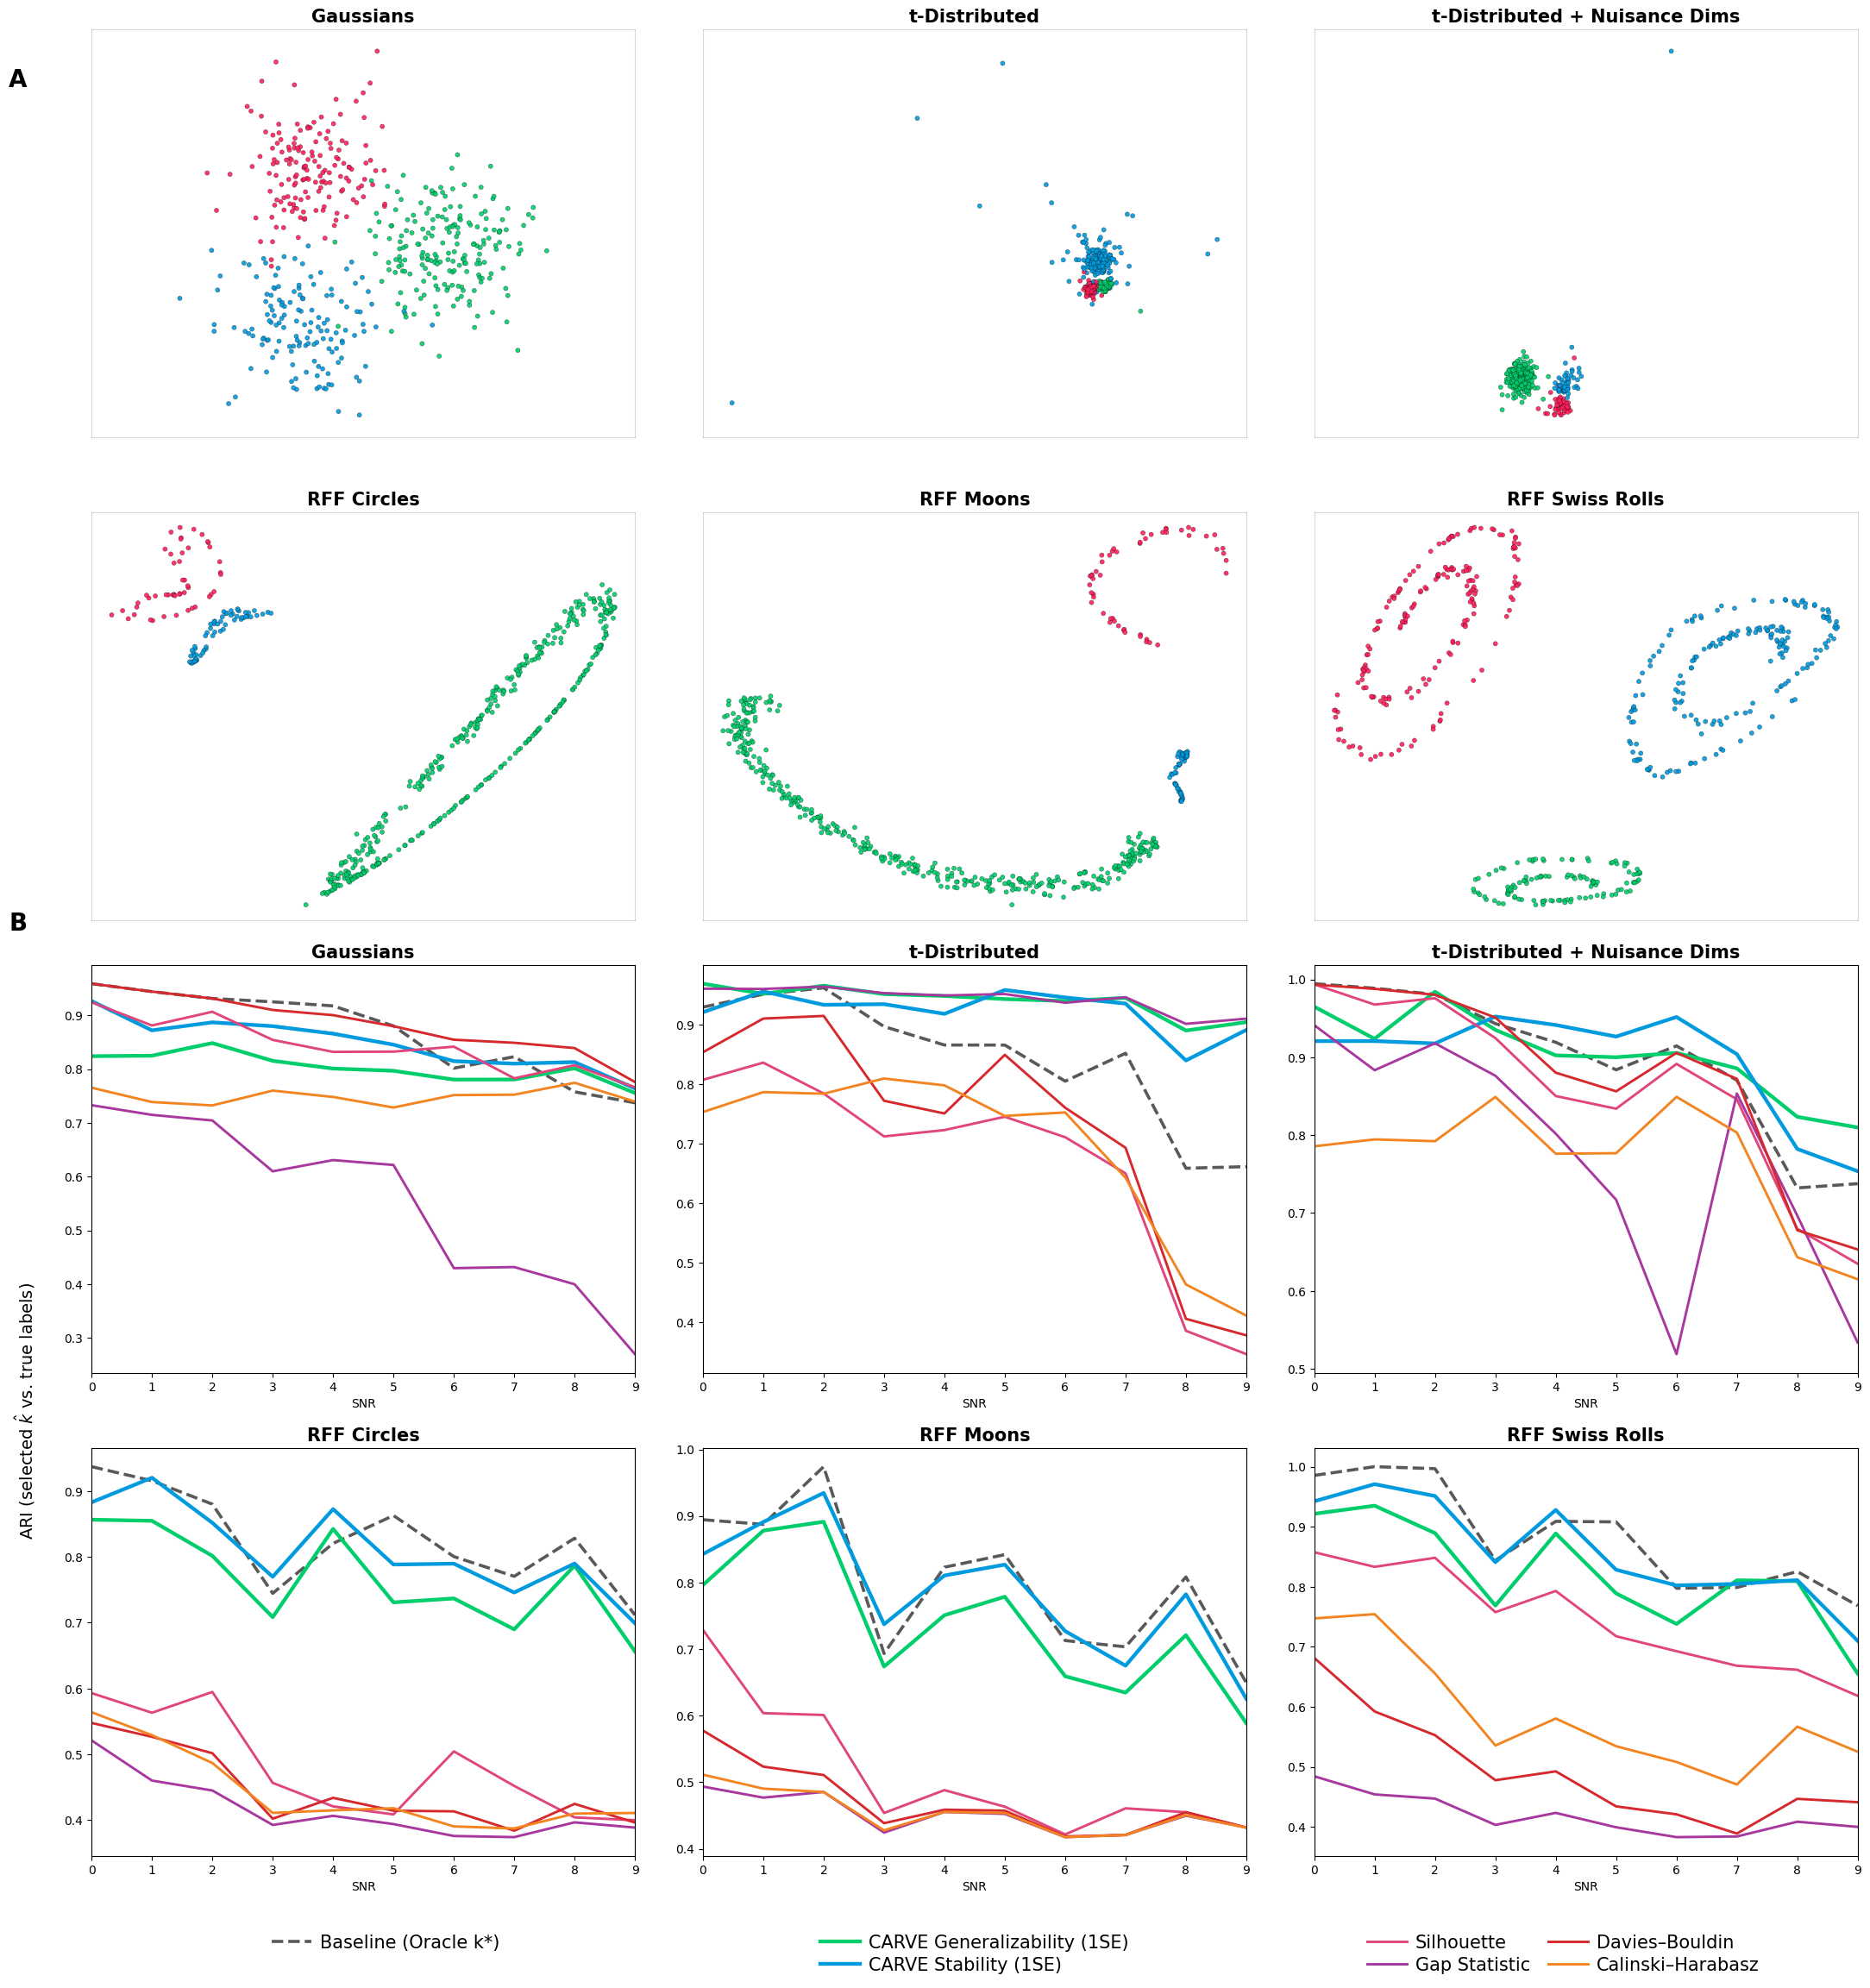

Saved paper_fig3_k3.pdf/.png


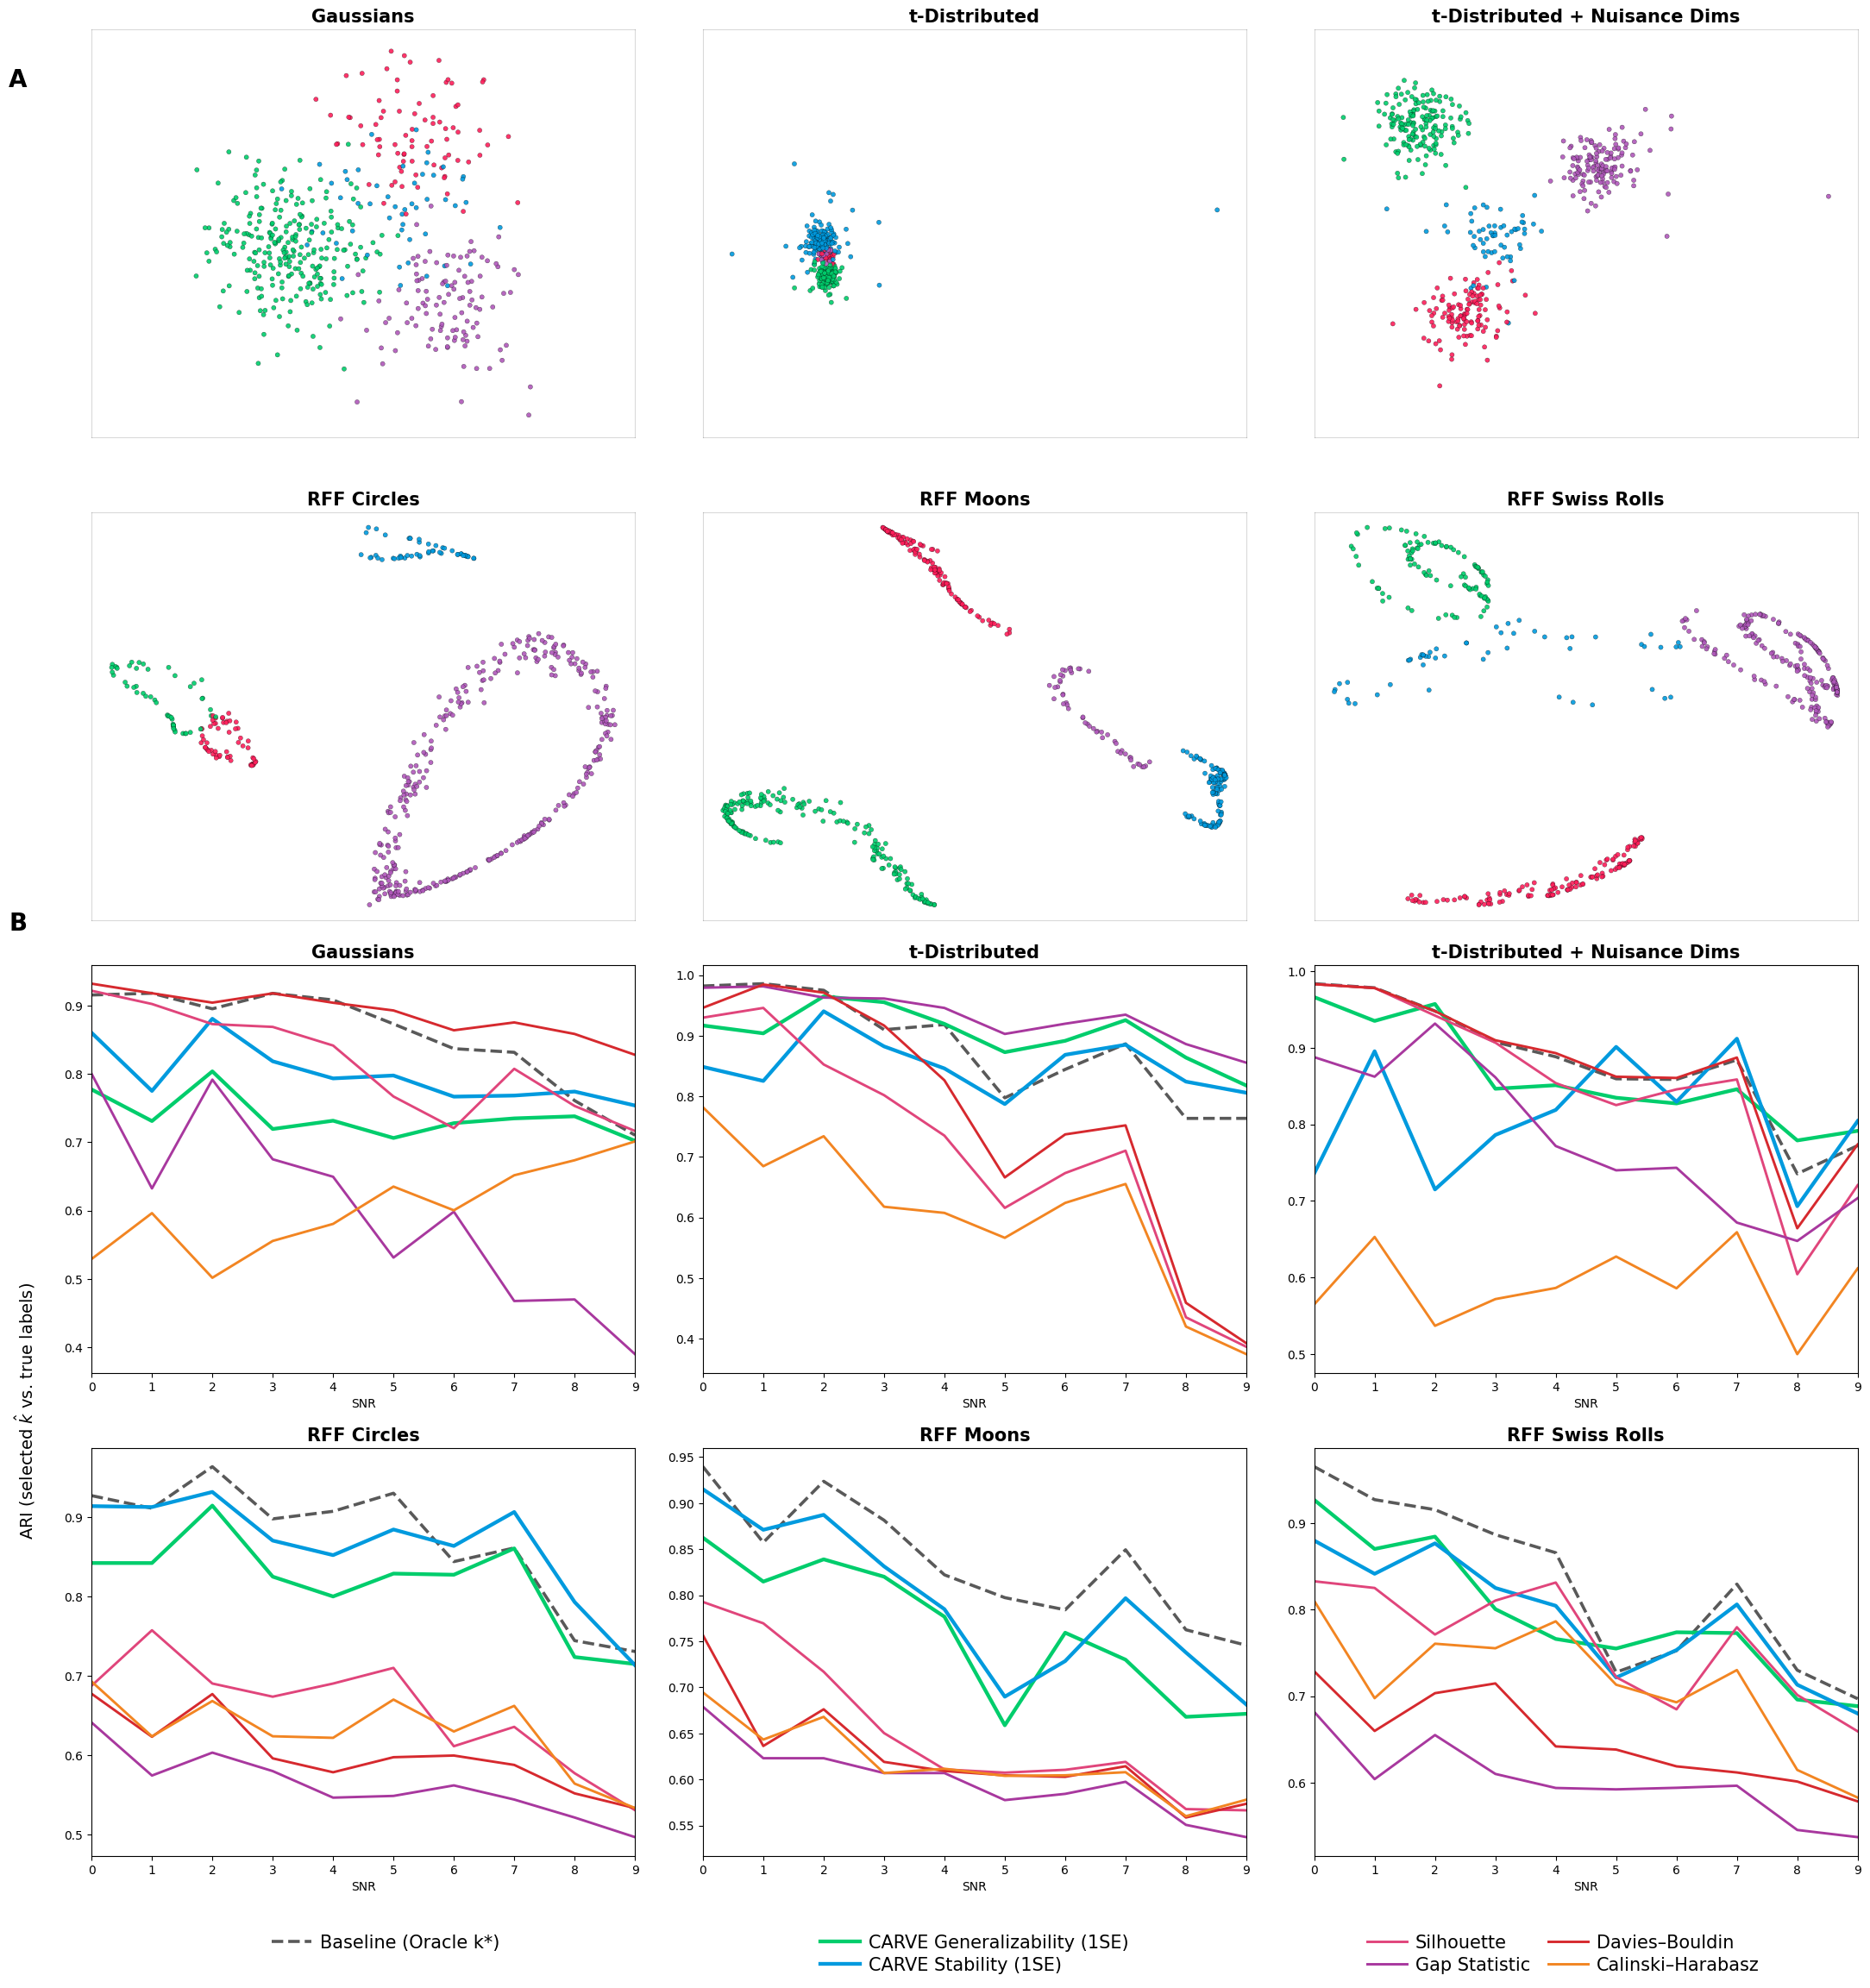

Saved paper_fig3_k4.pdf/.png


In [49]:
regimes_full = [
    (
        "Gaussians",
        results_gaussian,
        settings_by_k_gaussians,
        other_settings_gaussians,
        "kmeans",
    ),
    (
        "t-Distributed",
        results_t_dist,
        settings_by_k_t_dist,
        other_settings_t_dist,
        "agglomerative",
    ),
    (
        "t-Distributed + Nuisance Dims",
        results_t_dist_noise,
        settings_by_k_t_dist_noise,
        other_settings_t_dist_noise,
        "agglomerative",
    ),
    (
        "RFF Circles",
        results_circles,
        settings_by_k_circles,
        other_settings_circles,
        "spectral",
    ),
    ("RFF Moons", results_moons, settings_by_k_moons, other_settings_moons, "spectral"),
    (
        "RFF Swiss Rolls",
        results_swiss_rolls,
        settings_by_k_swiss_rolls,
        other_settings_swiss_rolls,
        "spectral",
    ),
]

os.makedirs("../vis/benchmarking/", exist_ok=True)

for k_star in [3, 4]:
    fig = plot_paper_figure(
        regimes_full,
        k_star=k_star,
        difficulty="hard",
        metrics=(
            "ari_generalizability_1se",
            "ari_stability_1se",
            "silhouette",
            "gap",
            "davies_bouldin",
            "calinski_harabasz",
        ),
        center="mean",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
        scale=1.75,
    )
    fig.savefig(f"../vis/benchmarking/paper_fig3_k{k_star}.pdf", bbox_inches="tight")
    fig.savefig(
        f"../vis/benchmarking/paper_fig3_k{k_star}.png", bbox_inches="tight", dpi=200
    )
    plt.show()
    print(f"Saved paper_fig3_k{k_star}.pdf/.png")

---